In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer

In [2]:
newsgroups = fetch_20newsgroups(
    subset='train',
    remove=('headers', 'footers', 'quotes')
)

documents = newsgroups.data

print("Number of Documents:", len(documents))

Number of Documents: 11314


In [3]:
vectorizer = CountVectorizer(
    stop_words='english',
    max_features=5000
)

X = vectorizer.fit_transform(documents)

print("Shape:", X.shape)

Shape: (11314, 5000)


In [4]:
word_counts = np.asarray(X.sum(axis=0)).flatten()

print("Vocabulary Size:", len(word_counts))
print("Total Words:", word_counts.sum())

Vocabulary Size: 5000
Total Words: 885959


In [5]:
mle_probs = word_counts / word_counts.sum()

print("Sum of probabilities:", mle_probs.sum())

Sum of probabilities: 1.0


In [6]:
def map_estimation(counts, alpha):
    V = len(counts)
    numerator = counts + alpha - 1
    denominator = counts.sum() + V * (alpha - 1)
    return numerator / denominator

In [7]:
alphas = [1, 2, 5, 10]

map_results = {}

for a in alphas:
    map_results[a] = map_estimation(word_counts, a)

In [11]:
feature_names = vectorizer.get_feature_names_out()

comparison = pd.DataFrame({
    "Word": feature_names[:10],
    "MLE": mle_probs[:10],
    "MAP α=2": map_results[2][:10],
    "MAP α=5": map_results[5][:10],
    "MAP α=10": map_results[10][:10]
})

comparison

,Word,MLE,MAP α=2,MAP α=5,MAP α=10
0,00,0.001359,0.001352,0.001333,0.001303
1,000,0.000782,0.000779,0.000769,0.000754
2,01,0.000257,0.000257,0.000256,0.000255
3,02,0.000296,0.000295,0.000294,0.000291
4,03,0.000238,0.000238,0.000237,0.000236
5,04,0.000393,0.000392,0.000389,0.000383
6,040,0.000047,0.000048,0.000051,0.000055
7,05,0.000192,0.000192,0.000192,0.000192
8,06,0.000183,0.000183,0.000183,0.000184
9,07,0.000086,0.000086,0.000088,0.000091


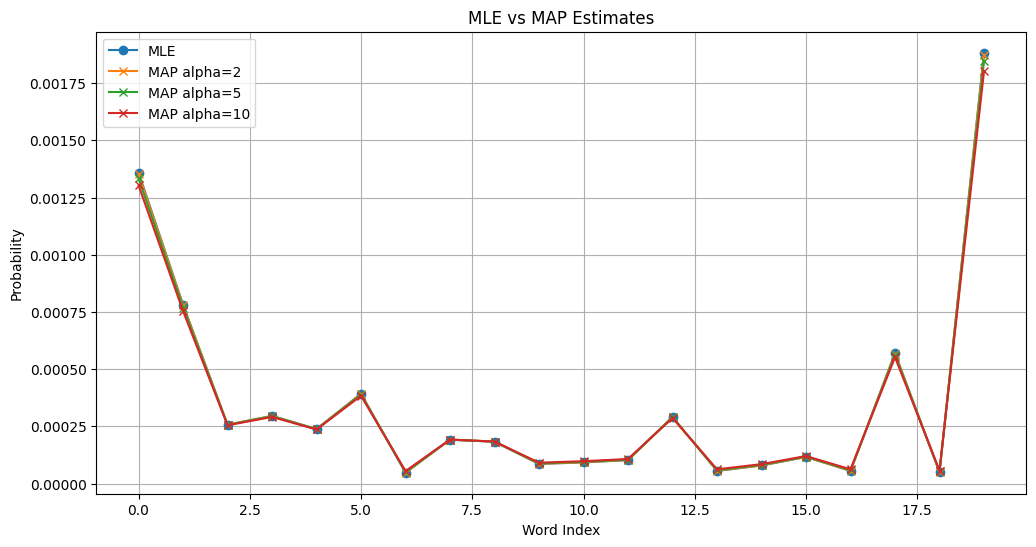

In [9]:
top = 20

plt.figure(figsize=(12,6))

plt.plot(mle_probs[:top], marker='o', label='MLE')

for a in [2,5,10]:
    plt.plot(map_results[a][:top], marker='x', label=f'MAP alpha={a}')

plt.xlabel("Word Index")
plt.ylabel("Probability")
plt.title("MLE vs MAP Estimates")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
print("MLE Sum:", mle_probs.sum())

for a in alphas:
    print(f"MAP alpha={a} Sum:", map_results[a].sum())

MLE Sum: 1.0
MAP alpha=1 Sum: 1.0
MAP alpha=2 Sum: 1.0
MAP alpha=5 Sum: 1.0
MAP alpha=10 Sum: 1.0
